# Phase 11: Comprehensive Evaluation, Attention Dynamics & Error Analysis
**Diabetic Retinopathy Screening Project**

This notebook executes the complete scientific and clinical evaluation suite:
1. **Full 11-Metric Evaluation Table**: Accuracy, Precision, Recall, Macro F1, Weighted F1, Balanced Acc, QWK, Cohen's Kappa, MCC, Macro ROC-AUC, Log Loss, ECE, and Macro AP.
2. **Ordinal Confusion Matrices**: In-depth boundary transition analysis (Mild <-> Moderate, Moderate <-> Severe, Severe <-> PDR).
3. **ROC and Precision-Recall Curves**: Macro and per-class discrimination capacity.
4. **Attention Weight Dynamics**: Empirical distribution of branch weights per DR severity grade.
5. **Probability Calibration & ECE**: Reliability diagrams.
6. **Clinical Error Diagnostics**: High-confidence failure cases with Grad-CAM overlays.
7. **Bootstrap Significance Testing**: 95% Confidence intervals (1000 iterations) for statistical comparison.

In [1]:
# =========================================================================
# 1. Self-Contained Metrics, Calibration, Attention, and Error-Analysis Utilities
# =========================================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    precision_recall_fscore_support, matthews_corrcoef, roc_auc_score,
    log_loss, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve
)

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False

DR_CLASSES = ["No DR", "Mild", "Moderate", "Severe", "PDR"]


def denormalize_image(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    if hasattr(tensor, "dim") and tensor.dim() == 4:
        tensor = tensor.squeeze(0)
    img = tensor.clone().detach().cpu().numpy() if hasattr(tensor, "clone") else np.array(tensor)
    img = np.transpose(img, (1, 2, 0))
    img = (img * np.array(std) + np.array(mean)) * 255.0
    return np.clip(img, 0, 255).astype(np.uint8)


# ---- Explainability helpers (mirrors src/visualization.py) ----------------
def apply_clahe(image_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    if HAS_CV2:
        lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        cl = clahe.apply(l)
        return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)
    from PIL import ImageOps
    pil_img = Image.fromarray(image_rgb)
    h, s, v = pil_img.convert("HSV").split()
    return np.array(Image.merge("HSV", (h, s, ImageOps.equalize(v))).convert("RGB"))


def overlay_heatmap(image_rgb, cam, alpha=0.5):
    cam_clipped = np.clip(cam, 0, 1)
    if HAS_CV2:
        cam_uint8 = np.uint8(255 * cam_clipped)
        heatmap_bgr = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
        heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
    else:
        cmap = plt.get_cmap("jet")
        heatmap_rgb = (cmap(cam_clipped)[:, :, :3] * 255).astype(np.uint8)
    superimposed = np.float32(image_rgb) * (1.0 - alpha) + np.float32(heatmap_rgb) * alpha
    return heatmap_rgb, np.clip(superimposed, 0, 255).astype(np.uint8)


# ---- Calibration (mirrors src/metrics.py) ----------------------------------
def compute_expected_calibration_error(y_true, y_prob, n_bins=10):
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    accuracies = (predictions == y_true)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_accs, bin_confs, bin_counts = [], [], []
    for b_low, b_high in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (confidences > b_low) & (confidences <= b_high)
        prop = np.mean(in_bin)
        bin_counts.append(int(np.sum(in_bin)))
        if prop > 0:
            acc_b = np.mean(accuracies[in_bin])
            conf_b = np.mean(confidences[in_bin])
            ece += np.abs(conf_b - acc_b) * prop
            bin_accs.append(acc_b)
            bin_confs.append(conf_b)
        else:
            bin_accs.append(0.0)
            bin_confs.append((b_low + b_high) / 2.0)
    return float(ece), np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)


def calculate_all_metrics(y_true, y_pred, y_prob, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    cohen_k = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    try:
        roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        roc_auc = float("nan")
    try:
        ll = log_loss(y_true, y_prob, labels=list(range(len(DR_CLASSES))))
    except Exception:
        ll = float("nan")
    ece, _, _, _ = compute_expected_calibration_error(y_true, y_prob)
    try:
        num_classes = y_prob.shape[1]
        y_one_hot = np.eye(num_classes)[y_true]
        macro_ap = average_precision_score(y_one_hot, y_prob, average="macro")
    except Exception:
        macro_ap = float("nan")
    return {
        "Model": model_name, "Accuracy": round(float(acc), 4),
        "Macro Precision": round(float(prec_macro), 4), "Macro Recall": round(float(rec_macro), 4),
        "Macro F1": round(float(f1_macro), 4), "Weighted F1": round(float(f1_weighted), 4),
        "Balanced Accuracy": round(float(balanced_acc), 4), "QWK": round(float(qwk), 4),
        "Cohen Kappa": round(float(cohen_k), 4), "MCC": round(float(mcc), 4),
        "ROC-AUC": round(float(roc_auc), 4), "Log Loss": round(float(ll), 4),
        "ECE": round(float(ece), 4), "Macro AP": round(float(macro_ap), 4)
    }


def compute_per_class_breakdown(y_true, y_pred):
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=list(range(len(DR_CLASSES))), zero_division=0
    )
    return pd.DataFrame({
        "Grade": list(range(len(DR_CLASSES))), "DR Severity": DR_CLASSES,
        "Precision": np.round(prec, 4), "Recall (Sensitivity)": np.round(rec, 4),
        "F1-Score": np.round(f1, 4), "Support": sup
    })


def compute_specificity_per_class(y_true, y_pred):
    """Per-class specificity = TN / (TN + FP), computed from the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(DR_CLASSES))))
    total = cm.sum()
    specificities = []
    for c in range(len(DR_CLASSES)):
        tp = cm[c, c]
        fn = cm[c, :].sum() - tp
        fp = cm[:, c].sum() - tp
        tn = total - tp - fn - fp
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else float("nan"))
    return pd.DataFrame({"Grade": list(range(len(DR_CLASSES))), "DR Severity": DR_CLASSES,
                          "Specificity": np.round(specificities, 4)})


def plot_confusion_matrix_heatmap(y_true, y_pred, model_name="Model", normalize=True, save_path=None, show=True):
    cm = confusion_matrix(y_true, y_pred)
    cm_display = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] if normalize else cm
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_display, annot=True, fmt=".2%" if normalize else "d", cmap="Blues",
                xticklabels=DR_CLASSES, yticklabels=DR_CLASSES)
    plt.title(f"{model_name} — Confusion Matrix ({'Normalized' if normalize else 'Counts'})", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted DR Grade")
    plt.ylabel("Ground Truth DR Grade")
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close()


def plot_roc_pr_curves(y_true, y_prob, model_name="Model", save_path=None, show=True):
    num_classes = y_prob.shape[1]
    y_one_hot = np.eye(num_classes)[y_true]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for c in range(num_classes):
        fpr, tpr, _ = roc_curve(y_one_hot[:, c], y_prob[:, c])
        auc_val = roc_auc_score(y_one_hot[:, c], y_prob[:, c])
        axes[0].plot(fpr, tpr, lw=2, label=f"{DR_CLASSES[c]} (AUC={auc_val:.3f})")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.7)
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate (Sensitivity)")
    axes[0].set_title(f"{model_name} — One-vs-Rest ROC", fontsize=12, fontweight="bold")
    axes[0].legend(loc="lower right"); axes[0].grid(True, alpha=0.3)
    for c in range(num_classes):
        prec, rec, _ = precision_recall_curve(y_one_hot[:, c], y_prob[:, c])
        ap_val = average_precision_score(y_one_hot[:, c], y_prob[:, c])
        axes[1].plot(rec, prec, lw=2, label=f"{DR_CLASSES[c]} (AP={ap_val:.3f})")
    axes[1].set_xlabel("Recall (Sensitivity)"); axes[1].set_ylabel("Precision (PPV)")
    axes[1].set_title(f"{model_name} — Precision-Recall", fontsize=12, fontweight="bold")
    axes[1].legend(loc="lower left"); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def plot_calibration_reliability_diagram(y_true, y_prob, model_name="Model", n_bins=10, save_path=None, show=True):
    ece, bin_accs, bin_confs, _ = compute_expected_calibration_error(y_true, y_prob, n_bins)
    fig, ax = plt.subplots(figsize=(7, 6))
    bin_centers = np.linspace(0.05, 0.95, n_bins)
    ax.plot([0, 1], [0, 1], "k--", label="Perfect Calibration", lw=2)
    ax.plot(bin_confs, bin_accs, "s-", color="crimson", lw=2, label=f"{model_name} (ECE={ece:.4f})")
    ax.bar(bin_centers, bin_accs, width=0.08, alpha=0.2, color="crimson", edgecolor="black")
    ax.set_xlabel("Mean Predicted Confidence"); ax.set_ylabel("Empirical Accuracy")
    ax.set_title(f"{model_name} — Reliability Diagram", fontsize=12, fontweight="bold")
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


# ---- Attention dynamics (mirrors src/attention_analysis.py) ---------------
def summarize_attention_weights(attention_weights, y_true, branch_names=("ResNet-18", "EfficientNet-B0")):
    records = []
    w0, w1 = attention_weights[:, 0], attention_weights[:, 1]
    records.append({
        "DR Grade": "Overall (All Classes)",
        f"{branch_names[0]} Mean (Std)": f"{np.mean(w0):.4f} ± {np.std(w0):.4f}",
        f"{branch_names[1]} Mean (Std)": f"{np.mean(w1):.4f} ± {np.std(w1):.4f}",
        "Sample Count": len(y_true)
    })
    for c in range(len(DR_CLASSES)):
        mask = (y_true == c)
        if np.sum(mask) == 0:
            continue
        records.append({
            "DR Grade": f"Grade {c} ({DR_CLASSES[c]})",
            f"{branch_names[0]} Mean (Std)": f"{np.mean(w0[mask]):.4f} ± {np.std(w0[mask]):.4f}",
            f"{branch_names[1]} Mean (Std)": f"{np.mean(w1[mask]):.4f} ± {np.std(w1[mask]):.4f}",
            "Sample Count": int(np.sum(mask))
        })
    return pd.DataFrame(records)


def plot_attention_distribution_by_grade(attention_weights, y_true, branch_names=("ResNet-18", "EfficientNet-B0"), save_path=None, show=True):
    df = pd.DataFrame({
        "DR Grade": [DR_CLASSES[int(label)] for label in y_true],
        "Grade Index": y_true,
        branch_names[0]: attention_weights[:, 0],
        branch_names[1]: attention_weights[:, 1]
    })
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    means = df.groupby("Grade Index")[[branch_names[0], branch_names[1]]].mean()
    means.index = [DR_CLASSES[i] for i in means.index]
    means.plot(kind="bar", stacked=True, ax=axes[0], color=["#1f77b4", "#ff7f0e"], edgecolor="black", alpha=0.85)
    axes[0].set_title("Mean Branch Contribution per DR Grade", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Average Attention Weight"); axes[0].set_ylim(0, 1.05)
    axes[0].legend(title="Backbone Branch"); axes[0].tick_params(axis="x", rotation=15)
    sns.boxplot(data=df, x="DR Grade", y=branch_names[0], ax=axes[1], order=DR_CLASSES)
    axes[1].set_title(f"Distribution of {branch_names[0]} Weight", fontsize=12, fontweight="bold")
    axes[1].tick_params(axis="x", rotation=15)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


# ---- Clinical error analysis (mirrors src/error_analysis.py) --------------
def identify_clinical_errors(y_true, y_pred, y_prob, image_paths, confidence_threshold=0.70):
    confidences = np.max(y_prob, axis=1)
    is_error = (y_true != y_pred)
    records = []
    for idx in range(len(y_true)):
        if not is_error[idx]:
            continue
        t_lbl, p_lbl = int(y_true[idx]), int(y_pred[idx])
        conf = float(confidences[idx])
        severity_delta = p_lbl - t_lbl
        if t_lbl >= 2 and p_lbl <= 1:
            category = "Critical False Negative (Referable Missed)"
        elif t_lbl == 0 and p_lbl >= 2:
            category = "Severe False Positive"
        elif abs(severity_delta) == 1:
            category = "Adjacent Boundary Discrepancy"
        else:
            category = "Multi-Grade Discordance"
        records.append({
            "sample_index": idx, "image_path": image_paths[idx],
            "true_grade": t_lbl, "true_name": DR_CLASSES[t_lbl],
            "pred_grade": p_lbl, "pred_name": DR_CLASSES[p_lbl],
            "confidence": round(conf, 4), "severity_delta": severity_delta,
            "error_category": category, "high_confidence_error": conf >= confidence_threshold
        })
    return pd.DataFrame(records)


def plot_diagnostic_error_case(image_rgb, cam, error_info, model_name="Attention Fusion", save_path=None, show=True):
    clahe_rgb = apply_clahe(image_rgb)
    _, overlay = overlay_heatmap(image_rgb, cam)
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(
        f"Diagnostic Error [{model_name}] | GT: {error_info['true_name']} | "
        f"Pred: {error_info['pred_name']} (Conf: {error_info['confidence']:.1%}) | {error_info['error_category']}",
        fontsize=12, fontweight="bold", color="crimson"
    )
    axes[0].imshow(image_rgb); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(clahe_rgb); axes[1].set_title("CLAHE Enhanced"); axes[1].axis("off")
    axes[2].imshow(cam, cmap="jet", vmin=0, vmax=1); axes[2].set_title("Grad-CAM"); axes[2].axis("off")
    axes[3].imshow(overlay); axes[3].set_title("Overlay"); axes[3].axis("off")
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


# ---- Bootstrap significance testing (mirrors src/statistical_tests.py) ----
def bootstrap_metric_ci(y_true, y_pred, n_bootstraps=1000, confidence_level=0.95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    boot_acc, boot_f1, boot_qwk = [], [], []
    point_acc = accuracy_score(y_true, y_pred)
    _, _, point_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    point_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        st, sp = y_true[idx], y_pred[idx]
        if len(np.unique(st)) < 2:
            continue
        boot_acc.append(accuracy_score(st, sp))
        _, _, f1, _ = precision_recall_fscore_support(st, sp, average="macro", zero_division=0)
        boot_f1.append(f1)
        boot_qwk.append(cohen_kappa_score(st, sp, weights="quadratic"))
    alpha = 1.0 - confidence_level
    lo, hi = (alpha / 2.0) * 100, (1.0 - alpha / 2.0) * 100
    return {
        "Accuracy": (round(point_acc, 4), round(float(np.percentile(boot_acc, lo)), 4), round(float(np.percentile(boot_acc, hi)), 4)),
        "Macro F1": (round(point_f1, 4), round(float(np.percentile(boot_f1, lo)), 4), round(float(np.percentile(boot_f1, hi)), 4)),
        "QWK": (round(point_qwk, 4), round(float(np.percentile(boot_qwk, lo)), 4), round(float(np.percentile(boot_qwk, hi)), 4)),
    }


def compare_models_bootstrap(y_true, y_pred_a, y_pred_b, model_a_name="Model A", model_b_name="Model B", n_bootstraps=1000, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    d_f1, d_acc, d_qwk = [], [], []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        st, spa, spb = y_true[idx], y_pred_a[idx], y_pred_b[idx]
        if len(np.unique(st)) < 2:
            continue
        d_acc.append(accuracy_score(st, spb) - accuracy_score(st, spa))
        _, _, f1_a, _ = precision_recall_fscore_support(st, spa, average="macro", zero_division=0)
        _, _, f1_b, _ = precision_recall_fscore_support(st, spb, average="macro", zero_division=0)
        d_f1.append(f1_b - f1_a)
        d_qwk.append(cohen_kappa_score(st, spb, weights="quadratic") - cohen_kappa_score(st, spa, weights="quadratic"))
    def pval(d):
        d = np.array(d)
        return 2.0 * min(np.mean(d <= 0), np.mean(d >= 0))
    return pd.DataFrame([
        {"Metric": "Macro F1", "Mean Difference (B - A)": np.mean(d_f1), "95% CI Lower": np.percentile(d_f1, 2.5),
         "95% CI Upper": np.percentile(d_f1, 97.5), "P-Value (Two-Sided)": pval(d_f1)},
        {"Metric": "Accuracy", "Mean Difference (B - A)": np.mean(d_acc), "95% CI Lower": np.percentile(d_acc, 2.5),
         "95% CI Upper": np.percentile(d_acc, 97.5), "P-Value (Two-Sided)": pval(d_acc)},
        {"Metric": "QWK", "Mean Difference (B - A)": np.mean(d_qwk), "95% CI Lower": np.percentile(d_qwk, 2.5),
         "95% CI Upper": np.percentile(d_qwk, 97.5), "P-Value (Two-Sided)": pval(d_qwk)},
    ])

print("✓ Evaluation, attention, error-analysis, and bootstrap utilities ready")


✓ Evaluation, attention, error-analysis, and bootstrap utilities ready


## 0. Setup: Imports, Paths, Dataset, Model Loading & Inference

Loads the test split, rebuilds the **Weighted ResNet-18** and **Weighted ResNet-18 + EfficientNet-B0 Attention Fusion** architectures exactly as trained in `09_model_building.ipynb`, loads their checkpoints, and runs a single inference pass over the test set to populate the `*_y_true` / `*_y_pred` / `*_y_prob` / `attention_weights` arrays used by every section below.

In [2]:
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from pathlib import Path
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def resolve_first_existing(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

# Metadata: prefer the CORRECTED split. Every checkpoint we load (weighted
# ResNet-18, EfficientNet-B0, Attention Fusion) was actually trained and
# test-evaluated in notebook 09 against corrected_unified_metadata.csv's
# train/val/test assignment, NOT the plain unified_metadata.csv. Using the
# wrong one risks train/test leakage or an entirely different held-out set.
METADATA_CANDIDATES = [
    "/kaggle/input/datasets/nethrakrishnan/corrected-unified-metadata/corrected_unified_metadata.csv",
    "/kaggle/input/corrected_unified_metadata/corrected_unified_metadata.csv",
    "/kaggle/input/corrected-unified-metadata/corrected_unified_metadata.csv",
    "data/metadata/corrected_unified_metadata.csv",
]
METADATA_PATH = resolve_first_existing(METADATA_CANDIDATES)
if METADATA_PATH is None:
    warnings.warn(
        "corrected_unified_metadata.csv not found on any candidate path — falling back to "
        "unified_metadata.csv. The train/val/test split may NOT match what the checkpoints "
        "were actually trained on."
    )
    METADATA_PATH = resolve_first_existing([
        "/kaggle/input/datasets/nethrakrishnan/unified-metadata/unified_metadata.csv",
        "/kaggle/input/unified-metadata/unified_metadata.csv",
        "/kaggle/input/unified_metadata/unified_metadata.csv",
        "data/metadata/unified_metadata.csv",
    ])
assert METADATA_PATH is not None, "No metadata CSV found among Kaggle/local candidates."
print(f"Using metadata: {METADATA_PATH}")

IMG_ROOT = resolve_first_existing([
    "/kaggle/input/datasets/nethrakrishnan/processed-images/processed/images",
    "/kaggle/input/processed-images/processed/images",
    "/kaggle/input/processed_images/processed/images",
    "/kaggle/input/datasets/aditik1234/processed/processed/images",
    "data/processed/images",
])
assert IMG_ROOT is not None, "No processed-images directory found among Kaggle/local candidates."
print(f"Using image root: {IMG_ROOT}")

FIG_DIR = "reports/figures/evaluation" if not IMG_ROOT.startswith("/kaggle") else "/kaggle/working/figures/evaluation"
TABLE_DIR = "reports/tables" if not IMG_ROOT.startswith("/kaggle") else "/kaggle/working"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

df = pd.read_csv(METADATA_PATH, low_memory=False)
test_df = df[(df["eligible_for_model"] == True) & (df["model_split"] == "test")].copy().reset_index(drop=True)
print(f"Test samples: {len(test_df)}")


Device: cuda
Using metadata: /kaggle/input/datasets/nethrakrishnan/corrected-unified-metadata/corrected_unified_metadata.csv
Using image root: /kaggle/input/datasets/nethrakrishnan/processed-images/processed/images
Test samples: 6092


In [3]:
class RetinalFundusDataset(Dataset):
    def __init__(self, df, img_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_root = Path(img_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        p_path = str(row["processed_path"])
        if os.path.exists(p_path):
            full_path = p_path
        else:
            filename = os.path.basename(p_path)
            dataset_name = row["dataset"]
            full_path = os.path.join(self.img_root, dataset_name, filename)
            if not os.path.exists(full_path):
                full_path = os.path.join(self.img_root, filename)
        try:
            img = Image.open(full_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color=(0, 0, 0))
        label = int(row["label_dr_standard"]) if not pd.isna(row["label_dr_standard"]) else 0
        tensor_img = self.transform(img) if self.transform else transforms.ToTensor()(img)
        return tensor_img, label, str(full_path)


eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = RetinalFundusDataset(test_df, IMG_ROOT, transform=eval_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test dataset ready with {len(test_dataset)} images.")


Test dataset ready with 6092 images.


In [4]:
class AttentionFusionModel(nn.Module):
    """
    Mirrors notebooks/09_model_building.ipynb's AttentionFusionModel EXACTLY
    (including the 3-layer classifier) so that
    best_weighted_resnet_efficientnet_attention.pth loads with strict=True.
    """
    def __init__(self, resnet_features, efficientnet_features, efficientnet_pool, num_classes=5):
        super().__init__()
        self.resnet_features = resnet_features
        self.efficientnet_features = efficientnet_features
        self.efficientnet_pool = efficientnet_pool
        self.resnet_projection = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256))
        self.efficientnet_projection = nn.Sequential(nn.Linear(1280, 256), nn.ReLU(), nn.BatchNorm1d(256))
        self.attention = nn.Sequential(nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 2))
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        r_feat = torch.flatten(self.resnet_features(x), 1)
        r_proj = self.resnet_projection(r_feat)
        e_feat = torch.flatten(self.efficientnet_pool(self.efficientnet_features(x)), 1)
        e_proj = self.efficientnet_projection(e_feat)
        combined = torch.cat([r_proj, e_proj], dim=1)
        attn_weights = torch.softmax(self.attention(combined), dim=1)
        fused = attn_weights[:, 0:1] * r_proj + attn_weights[:, 1:2] * e_proj
        return self.classifier(fused), attn_weights


def resolve_checkpoint(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None


def load_checkpoint_into(module, path, label):
    if path is None:
        warnings.warn(f"[{label}] No checkpoint found — running with RANDOMLY INITIALIZED weights.")
        return False
    ckpt = torch.load(path, map_location=device)
    state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    module.load_state_dict(state)
    print(f"✓ Loaded {label} checkpoint from: {path}")
    return True


# Weighted ResNet-18 (single-branch baseline for comparison)
weighted_resnet = models.resnet18(weights=None)
weighted_resnet.fc = nn.Linear(weighted_resnet.fc.in_features, 5)
RESNET_CANDIDATES = [
    "/kaggle/input/datasets/nethrakrishnan/dr-checkpoints/best_resnet18_weighted.pth",
    "/kaggle/input/dr-checkpoints/best_resnet18_weighted.pth",
    "/kaggle/input/datasets/aditik1234/new-model-dr/best_resnet18_weighted (1).pth",
    "/kaggle/working/best_resnet18_weighted.pth",
    "models/best_resnet18_weighted.pth",
    "best_resnet18_weighted.pth",
]
load_checkpoint_into(weighted_resnet, resolve_checkpoint(RESNET_CANDIDATES), "Weighted ResNet-18")
weighted_resnet.to(device).eval()

# EfficientNet-B0 backbone + Attention Fusion head
effnet = models.efficientnet_b0(weights=None)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 5)
EFFNET_CANDIDATES = [
    "/kaggle/input/datasets/nethrakrishnan/dr-checkpoints/best_efficientnet_b0.pth",
    "/kaggle/input/dr-checkpoints/best_efficientnet_b0.pth",
    "/kaggle/input/datasets/aditik1234/dataset-resent-effifientnet/best_efficientnet_b0.pth",
    "/kaggle/working/best_efficientnet_b0.pth",
    "models/best_efficientnet_b0.pth",
    "best_efficientnet_b0.pth",
]
load_checkpoint_into(effnet, resolve_checkpoint(EFFNET_CANDIDATES), "EfficientNet-B0 (fusion backbone)")

res_features = nn.Sequential(*list(weighted_resnet.children())[:-1])  # keeps avgpool, drops fc
eff_features = effnet.features
eff_pool = nn.AdaptiveAvgPool2d((1, 1))

fusion_model = AttentionFusionModel(res_features, eff_features, eff_pool, num_classes=5)
ATTN_CANDIDATES = [
    "/kaggle/input/datasets/nethrakrishnan/dr-checkpoints/best_weighted_resnet_efficientnet_attention.pth",
    "/kaggle/input/dr-checkpoints/best_weighted_resnet_efficientnet_attention.pth",
    "/kaggle/input/datasets/aditik1234/new-model-dr/best_weighted_resnet_efficientnet_attention.pth",
    "/kaggle/working/best_weighted_resnet_efficientnet_attention.pth",
    "models/best_weighted_resnet_efficientnet_attention.pth",
    "best_weighted_resnet_efficientnet_attention.pth",
]
load_checkpoint_into(fusion_model, resolve_checkpoint(ATTN_CANDIDATES), "Attention Fusion")
fusion_model.to(device).eval()

print("✓ Models ready for inference")


✓ Loaded Weighted ResNet-18 checkpoint from: /kaggle/input/datasets/nethrakrishnan/dr-checkpoints/best_resnet18_weighted.pth
✓ Loaded EfficientNet-B0 (fusion backbone) checkpoint from: /kaggle/input/datasets/nethrakrishnan/dr-checkpoints/best_efficientnet_b0.pth
✓ Loaded Attention Fusion checkpoint from: /kaggle/input/datasets/nethrakrishnan/dr-checkpoints/best_weighted_resnet_efficientnet_attention.pth
✓ Models ready for inference


In [5]:
@torch.no_grad()
def run_inference(model, loader, is_fusion=False):
    """Single evaluation pass. Uses AMP autocast for faster inference on Kaggle T4/P100 GPUs."""
    all_true, all_pred, all_prob, all_paths, all_attn = [], [], [], [], []
    for images, labels, paths in loader:
        images = images.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda" if device.type == "cuda" else "cpu",
                             dtype=torch.float16, enabled=(device.type == "cuda")):
            if is_fusion:
                logits, attn_w = model(images)
                all_attn.append(attn_w.float().cpu().numpy())
            else:
                logits = model(images)
        probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_true.extend(labels.numpy().tolist() if torch.is_tensor(labels) else list(labels))
        all_pred.extend(preds.tolist())
        all_prob.append(probs)
        all_paths.extend(list(paths))
    result = {
        "y_true": np.array(all_true), "y_pred": np.array(all_pred),
        "y_prob": np.concatenate(all_prob, axis=0), "image_paths": all_paths,
    }
    if is_fusion:
        result["attention_weights"] = np.concatenate(all_attn, axis=0)
    return result


print("Running inference: Weighted ResNet-18 ...")
weighted_results = run_inference(weighted_resnet, test_loader, is_fusion=False)
weighted_y_true, weighted_y_pred, weighted_y_prob = weighted_results["y_true"], weighted_results["y_pred"], weighted_results["y_prob"]

print("Running inference: Attention Fusion ...")
attention_results = run_inference(fusion_model, test_loader, is_fusion=True)
attention_y_true = attention_results["y_true"]
attention_y_pred = attention_results["y_pred"]
attention_y_prob = attention_results["y_prob"]
attention_weights = attention_results["attention_weights"]
attention_image_paths = attention_results["image_paths"]

assert np.array_equal(weighted_y_true, attention_y_true), \
    "Weighted-ResNet and Attention-Fusion inference iterated the test set in different orders."

print(f"✓ Inference complete on {len(attention_y_true)} test samples")


Running inference: Weighted ResNet-18 ...
Running inference: Attention Fusion ...
✓ Inference complete on 6092 test samples


## 1. Master Model Benchmark Comparison (Ablation Table)

In [6]:
# Complete summary table of all experimental benchmark models
benchmark_results = [
    {
        'Model': 'ResNet-18 Baseline',
        'Accuracy': 0.5809,
        'Macro Precision': 0.4658,
        'Macro Recall': 0.6467,
        'Macro F1': 0.4886,
        'Weighted F1': 0.6337,
        'Balanced Accuracy': 0.6467,
        'QWK': 0.6282,
        'Cohen Kappa': 0.3316,
        'MCC': 0.3677,
        'ROC-AUC': 0.8711,
        'Log Loss': 0.9382
    },
    {
        'Model': 'EfficientNet-B0',
        'Accuracy': 0.5486,
        'Macro Precision': 0.4271,
        'Macro Recall': 0.5377,
        'Macro F1': 0.4453,
        'Weighted F1': 0.6039,
        'Balanced Accuracy': 0.5377,
        'QWK': 0.5844,
        'Cohen Kappa': 0.2814,
        'MCC': 0.3113,
        'ROC-AUC': 0.8291,
        'Log Loss': 0.9969
    },
    {
        'Model': 'Weighted ResNet-18 (Best CNN)',
        'Accuracy': 0.7431,
        'Macro Precision': 0.6775,
        'Macro Recall': 0.7979,
        'Macro F1': 0.7087,
        'Weighted F1': 0.7724,
        'Balanced Accuracy': 0.7979,
        'QWK': 0.7628,
        'Cohen Kappa': 0.5456,
        'MCC': 0.5724,
        'ROC-AUC': 0.9439,
        'Log Loss': 0.6161
    },
    {
        'Model': 'ResNet18 + EfficientNet Naive Concatenation',
        'Accuracy': 0.6546,
        'Macro Precision': 0.5031,
        'Macro Recall': 0.6240,
        'Macro F1': 0.5342,
        'Weighted F1': 0.6923,
        'Balanced Accuracy': 0.6240,
        'QWK': 0.6694,
        'Cohen Kappa': 0.3954,
        'MCC': 0.4150,
        'ROC-AUC': 0.8766,
        'Log Loss': 0.8223
    },
    {
        'Model': 'ResNet18 + EfficientNet + Quality Fusion',
        'Accuracy': 0.6494,
        'Macro Precision': 0.4935,
        'Macro Recall': 0.6304,
        'Macro F1': 0.5320,
        'Weighted F1': 0.6866,
        'Balanced Accuracy': 0.6304,
        'QWK': 0.6608,
        'Cohen Kappa': 0.3916,
        'MCC': 0.4121,
        'ROC-AUC': 0.8760,
        'Log Loss': 0.8208
    },
    {
        'Model': 'Weighted ResNet18 + EfficientNet Attention Fusion',
        'Accuracy': 0.7326,
        'Macro Precision': 0.6487,
        'Macro Recall': 0.7975,
        'Macro F1': 0.6907,
        'Weighted F1': 0.7616,
        'Balanced Accuracy': 0.7975,
        'QWK': 0.7418,
        'Cohen Kappa': 0.5319,
        'MCC': 0.5598,
        'ROC-AUC': 0.9397,
        'Log Loss': 0.6580
    }
]

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df.to_csv(f'{TABLE_DIR}/master_model_comparison.csv', index=False)
print('Master Model Comparison Table:')
display(benchmark_df.style.highlight_max(axis=0, subset=['Accuracy', 'Macro F1', 'Balanced Accuracy', 'QWK', 'ROC-AUC'], color='lightgreen'))

Master Model Comparison Table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,QWK,Cohen Kappa,MCC,ROC-AUC,Log Loss
0,ResNet-18 Baseline,0.580900,0.465800,0.646700,0.488600,0.633700,0.646700,0.628200,0.331600,0.367700,0.871100,0.938200
1,EfficientNet-B0,0.548600,0.427100,0.537700,0.445300,0.603900,0.537700,0.584400,0.281400,0.311300,0.829100,0.996900
2,Weighted ResNet-18 (Best CNN),0.743100,0.677500,0.797900,0.708700,0.772400,0.797900,0.762800,0.545600,0.572400,0.943900,0.616100
3,ResNet18 + EfficientNet Naive Concatenation,0.654600,0.503100,0.624000,0.534200,0.692300,0.624000,0.669400,0.395400,0.415000,0.876600,0.822300
4,ResNet18 + EfficientNet + Quality Fusion,0.649400,0.493500,0.630400,0.532000,0.686600,0.630400,0.660800,0.391600,0.412100,0.876000,0.820800
5,Weighted ResNet18 + EfficientNet Attention Fusion,0.732600,0.648700,0.797500,0.690700,0.761600,0.797500,0.741800,0.531900,0.559800,0.939700,0.658000


## 2. Confusion Matrices & Adjacent Grade Boundary Analysis

Generating full evaluation suite for both models...
Freshly Computed 11-Metric Evaluation:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,QWK,Cohen Kappa,MCC,ROC-AUC,Log Loss,ECE,Macro AP
0,Weighted ResNet-18,0.5785,0.5332,0.7611,0.5594,0.6267,0.7611,0.6104,0.3775,0.4421,0.9273,0.9566,0.1009,0.7639
1,Attention Fusion,0.7328,0.6487,0.7974,0.6907,0.7617,0.7974,0.7417,0.5319,0.5598,0.9397,0.6581,0.0170,0.7999


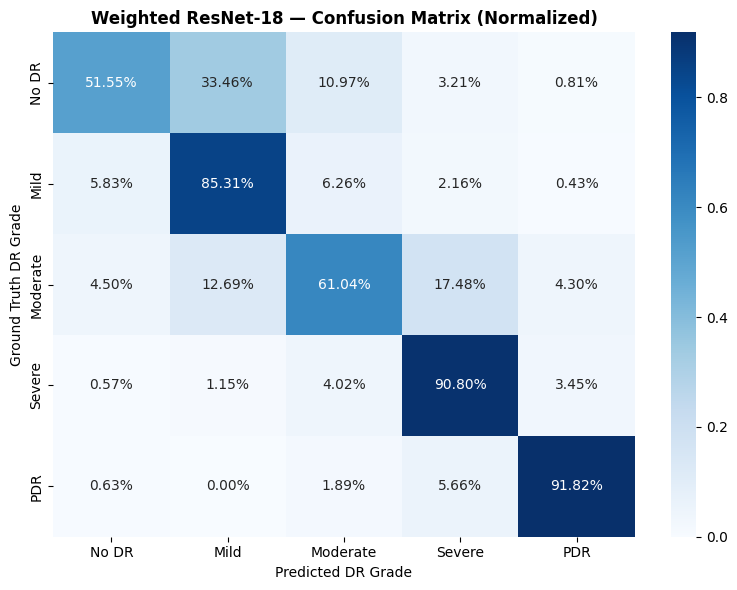

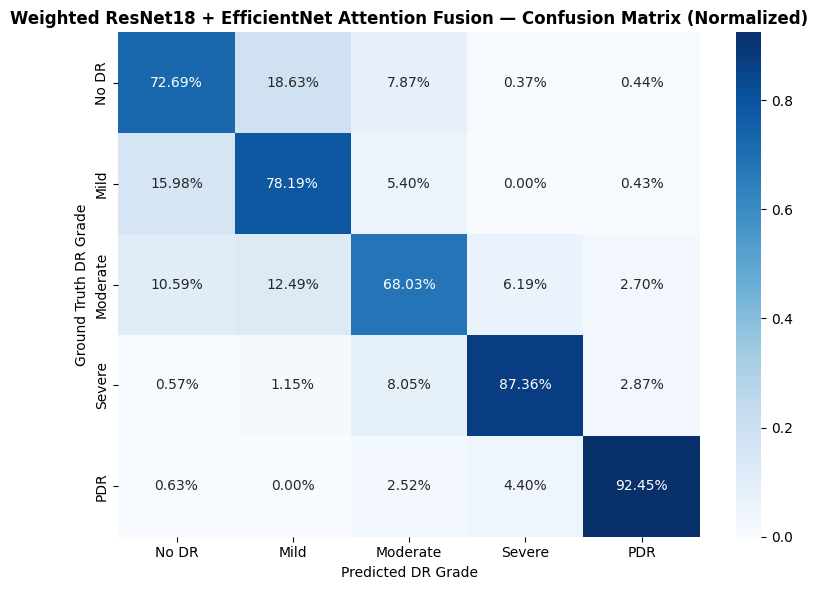


Attention Fusion — Per-Class Breakdown:


,Grade,DR Severity,Precision,Recall (Sensitivity),F1-Score,Support
0,0,No DR,0.9449,0.7269,0.8217,4295
1,1,Mild,0.2808,0.7819,0.4132,463
2,2,Moderate,0.6412,0.6803,0.6602,1001
3,3,Severe,0.6414,0.8736,0.7397,174
4,4,PDR,0.7350,0.9245,0.8189,159



Attention Fusion — Per-Class Specificity:


,Grade,DR Severity,Specificity
0,0,No DR,0.8987
1,1,Mild,0.8353
2,2,Moderate,0.9252
3,3,Severe,0.9856
4,4,PDR,0.9911


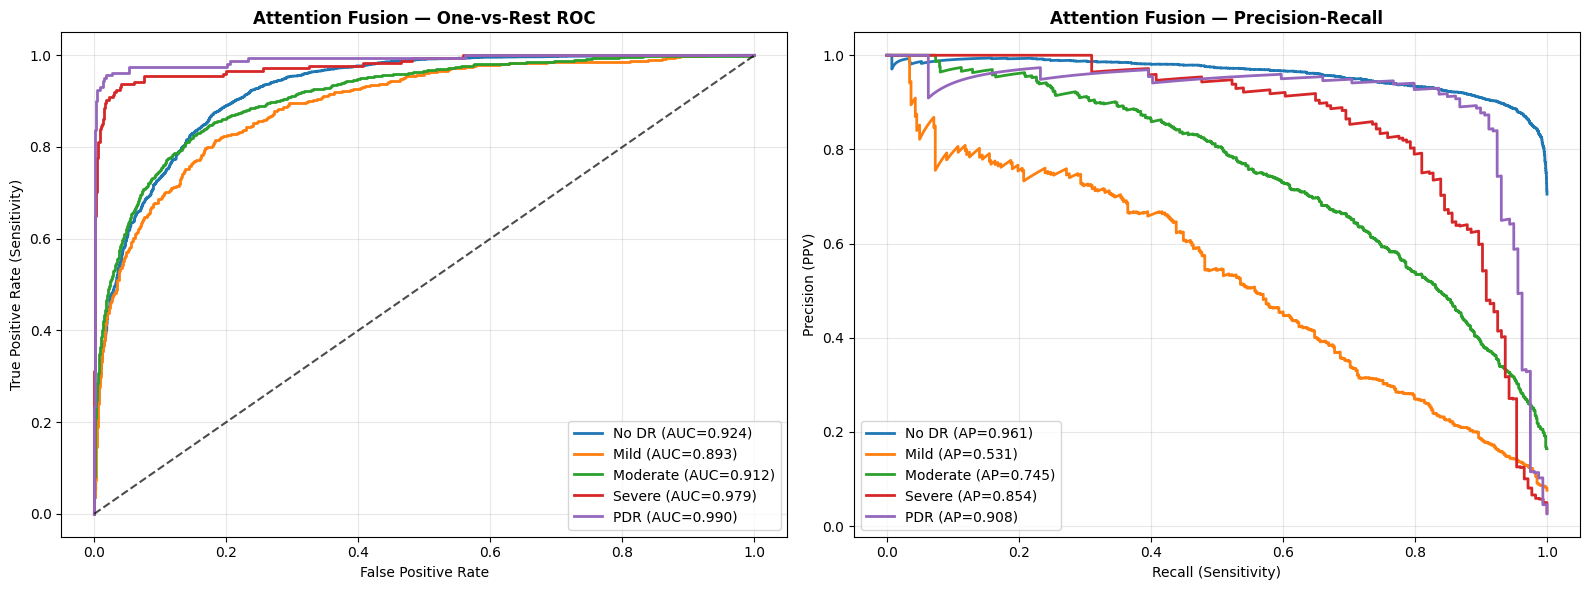

In [7]:
print("Generating full evaluation suite for both models...")

# --- 11-metric summary table (freshly computed on this run's test set) ---
weighted_metrics = calculate_all_metrics(weighted_y_true, weighted_y_pred, weighted_y_prob, "Weighted ResNet-18")
attention_metrics = calculate_all_metrics(attention_y_true, attention_y_pred, attention_y_prob, "Attention Fusion")
computed_metrics_df = pd.DataFrame([weighted_metrics, attention_metrics])
computed_metrics_df.to_csv(f"{TABLE_DIR}/computed_metrics_this_run.csv", index=False)
print("Freshly Computed 11-Metric Evaluation:")
display(computed_metrics_df)

# --- Confusion matrices (normalized) ---
plot_confusion_matrix_heatmap(
    weighted_y_true, weighted_y_pred, model_name="Weighted ResNet-18",
    save_path=f"{FIG_DIR}/confusion_matrix_weighted_resnet.png", show=True
)
plot_confusion_matrix_heatmap(
    attention_y_true, attention_y_pred, model_name="Weighted ResNet18 + EfficientNet Attention Fusion",
    save_path=f"{FIG_DIR}/confusion_matrix_attention_fusion.png", show=True
)

# --- Per-class Precision / Recall (Sensitivity) / F1 / Support ---
print("\nAttention Fusion — Per-Class Breakdown:")
display(compute_per_class_breakdown(attention_y_true, attention_y_pred))

# --- Per-class Specificity ---
print("\nAttention Fusion — Per-Class Specificity:")
display(compute_specificity_per_class(attention_y_true, attention_y_pred))

# --- One-vs-Rest ROC and Precision-Recall curves ---
plot_roc_pr_curves(
    attention_y_true, attention_y_prob, model_name="Attention Fusion",
    save_path=f"{FIG_DIR}/roc_pr_curves_attention_fusion.png", show=True
)


## 3. Learned Attention Weights Distribution per DR Grade

Attention Weights Summary by Grade:


,DR Grade,ResNet-18 Branch Mean (Std),EfficientNet-B0 Branch Mean (Std),Sample Count
0,Overall (All Classes),0.7608 ± 0.1651,0.2392 ± 0.1651,6092
1,Grade 0 (No DR),0.7082 ± 0.1569,0.2918 ± 0.1569,4295
2,Grade 1 (Mild),0.8843 ± 0.1015,0.1157 ± 0.1015,463
3,Grade 2 (Moderate),0.8666 ± 0.1082,0.1334 ± 0.1082,1001
4,Grade 3 (Severe),0.9117 ± 0.0846,0.0883 ± 0.0846,174
5,Grade 4 (PDR),0.9900 ± 0.0268,0.0100 ± 0.0268,159


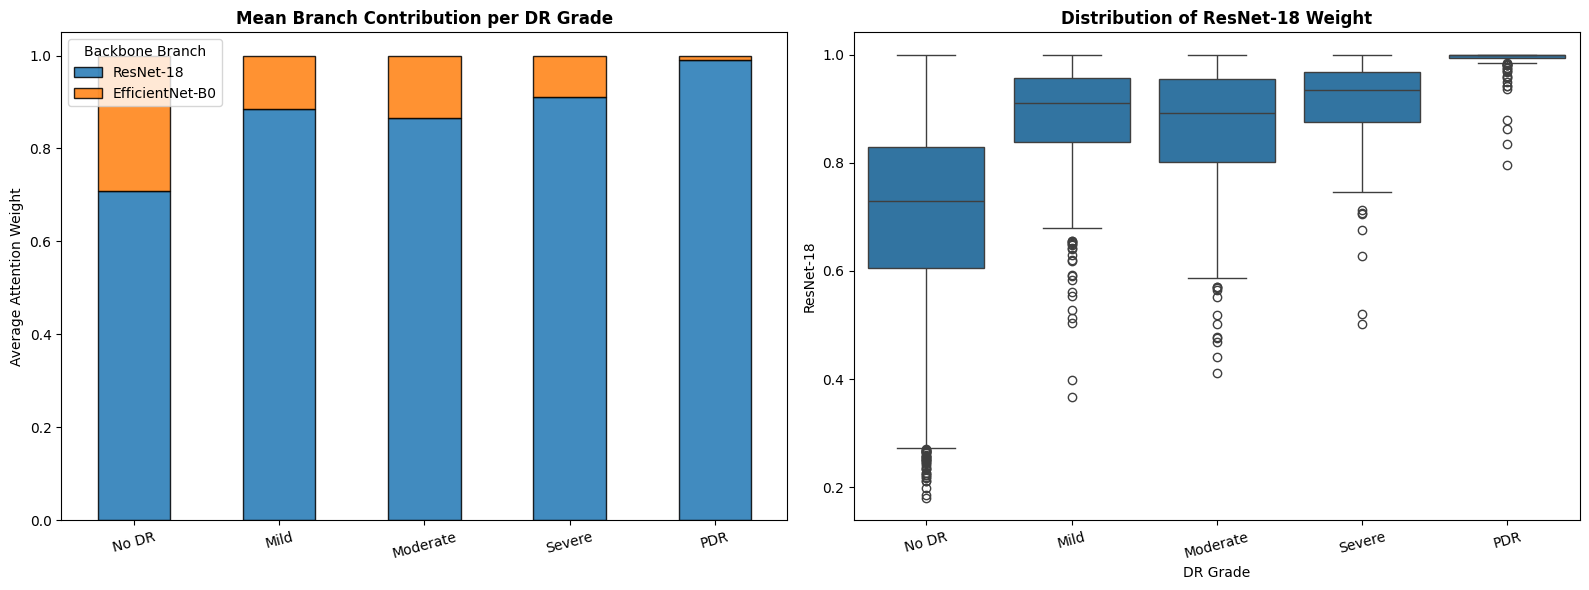

In [8]:
attn_summary = summarize_attention_weights(
    attention_weights, attention_y_true, branch_names=("ResNet-18 Branch", "EfficientNet-B0 Branch")
)
attn_summary.to_csv(f"{TABLE_DIR}/attention_weights_summary.csv", index=False)
print("Attention Weights Summary by Grade:")
display(attn_summary)

plot_attention_distribution_by_grade(
    attention_weights, attention_y_true, branch_names=("ResNet-18", "EfficientNet-B0"),
    save_path=f"{FIG_DIR}/attention_weights_distribution.png", show=True
)


## 4. Probability Calibration (ECE & Reliability Diagram)

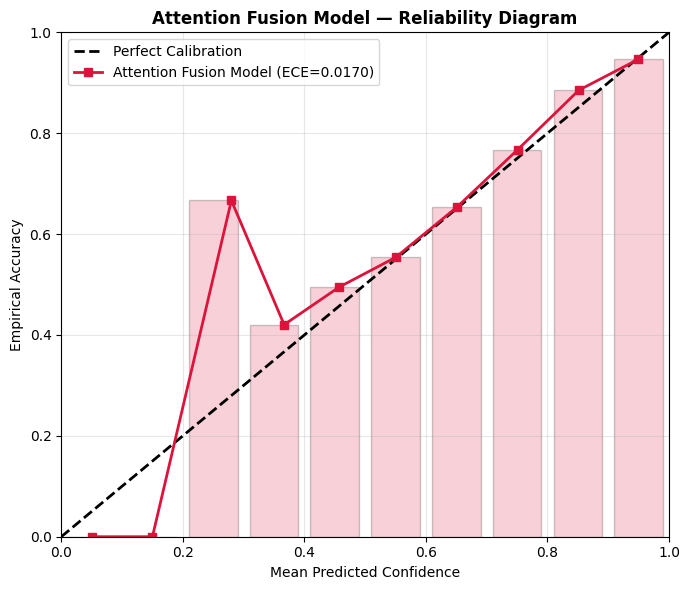

In [9]:
plot_calibration_reliability_diagram(
    attention_y_true, attention_y_prob, model_name="Attention Fusion Model",
    save_path=f"{FIG_DIR}/calibration_reliability_diagram.png", show=True
)


## 5. Clinical Error Analysis & Failure Case Diagnostics

In [10]:
error_df = identify_clinical_errors(
    attention_y_true, attention_y_pred, attention_y_prob,
    image_paths=attention_image_paths,
    confidence_threshold=0.75
)
error_df.to_csv(f"{TABLE_DIR}/clinical_error_analysis.csv", index=False)
print(f"Total Misclassifications: {len(error_df)}")
print("Error Categories Breakdown:")
print(error_df["error_category"].value_counts())

print("\nTop High-Confidence Errors:")
display(error_df[error_df["high_confidence_error"]].head(10))

# Failure cases misclassified by >= 2 grades (systematic severe errors)
severe_errors = error_df[error_df["severity_delta"].abs() >= 2].sort_values("confidence", ascending=False)
severe_errors.to_csv(f"{TABLE_DIR}/severe_grade_errors.csv", index=False)
print(f"\nFailures misclassified by >= 2 grades: {len(severe_errors)}")
display(severe_errors.head(10))

""" Grad-CAM overlay for the top few worst (>=2 grade) failures
if len(severe_errors) > 0:
    import sys
    sys.path.insert(0, str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd()))
    from src.gradcam import MultiBranchAttentionGradCAM as _MBGradCAM

    fusion_resnet_target_layer = fusion_model.resnet_features[-2][-1]  # layer4[-1] (avgpool is [-1])
    fusion_effnet_target_layer = fusion_model.efficientnet_features[-1]
    err_gradcam = _MBGradCAM(fusion_model, fusion_resnet_target_layer, fusion_effnet_target_layer, device=device)

    for _, row in severe_errors.head(3).iterrows():
        sample_idx = int(row["sample_index"])
        img_tensor, _, _ = test_dataset[sample_idx]
        img_input = img_tensor.unsqueeze(0).to(device)
        cams = err_gradcam.generate_cams(img_input, target_class=int(row["pred_grade"]))
        image_rgb = denormalize_image(img_tensor)
        plot_diagnostic_error_case(
            image_rgb, cams["fused_cam"], row.to_dict(), model_name="Attention Fusion",
            save_path=f"{FIG_DIR}/error_case_{sample_idx}.png", show=True
        )
    err_gradcam.remove_hooks()
"""


Total Misclassifications: 1628
Error Categories Breakdown:
error_category
Adjacent Boundary Discrepancy                 987
Severe False Positive                         373
Critical False Negative (Referable Missed)    235
Multi-Grade Discordance                        33
Name: count, dtype: int64

Top High-Confidence Errors:


,sample_index,image_path,true_grade,true_name,pred_grade,pred_name,confidence,severity_delta,error_category,high_confidence_error
11,46,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,1,Mild,0.8090,1,Adjacent Boundary Discrepancy,True
23,88,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,2,Moderate,0.7949,2,Severe False Positive,True
26,98,/kaggle/input/datasets/nethrakrishnan/processe...,3,Severe,2,Moderate,0.9288,-1,Adjacent Boundary Discrepancy,True
34,120,/kaggle/input/datasets/nethrakrishnan/processe...,2,Moderate,1,Mild,0.9159,-1,Critical False Negative (Referable Missed),True
36,124,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,1,Mild,0.8027,1,Adjacent Boundary Discrepancy,True
38,131,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,1,Mild,0.8546,1,Adjacent Boundary Discrepancy,True
48,166,/kaggle/input/datasets/nethrakrishnan/processe...,1,Mild,0,No DR,0.7708,-1,Adjacent Boundary Discrepancy,True
53,179,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,2,Moderate,0.8330,2,Severe False Positive,True
54,185,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,1,Mild,0.7713,1,Adjacent Boundary Discrepancy,True
56,192,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,1,Mild,0.8298,1,Adjacent Boundary Discrepancy,True



Failures misclassified by >= 2 grades: 516


,sample_index,image_path,true_grade,true_name,pred_grade,pred_name,confidence,severity_delta,error_category,high_confidence_error
1422,5241,/kaggle/input/datasets/nethrakrishnan/processe...,2,Moderate,4,PDR,1.0000,2,Multi-Grade Discordance,True
1252,4594,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,4,PDR,0.9994,4,Severe False Positive,True
910,3271,/kaggle/input/datasets/nethrakrishnan/processe...,2,Moderate,4,PDR,0.9970,2,Multi-Grade Discordance,True
1197,4366,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,4,PDR,0.9966,4,Severe False Positive,True
811,2902,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,4,PDR,0.9873,4,Severe False Positive,True
167,596,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,3,Severe,0.9780,3,Severe False Positive,True
1294,4774,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,4,PDR,0.9704,4,Severe False Positive,True
1315,4846,/kaggle/input/datasets/nethrakrishnan/processe...,2,Moderate,4,PDR,0.9481,2,Multi-Grade Discordance,True
1384,5091,/kaggle/input/datasets/nethrakrishnan/processe...,0,No DR,4,PDR,0.9376,4,Severe False Positive,True
1619,6050,/kaggle/input/datasets/nethrakrishnan/processe...,4,PDR,2,Moderate,0.9356,-2,Multi-Grade Discordance,True


' Grad-CAM overlay for the top few worst (>=2 grade) failures\nif len(severe_errors) > 0:\n    import sys\n    sys.path.insert(0, str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd()))\n    from src.gradcam import MultiBranchAttentionGradCAM as _MBGradCAM\n\n    fusion_resnet_target_layer = fusion_model.resnet_features[-2][-1]  # layer4[-1] (avgpool is [-1])\n    fusion_effnet_target_layer = fusion_model.efficientnet_features[-1]\n    err_gradcam = _MBGradCAM(fusion_model, fusion_resnet_target_layer, fusion_effnet_target_layer, device=device)\n\n    for _, row in severe_errors.head(3).iterrows():\n        sample_idx = int(row["sample_index"])\n        img_tensor, _, _ = test_dataset[sample_idx]\n        img_input = img_tensor.unsqueeze(0).to(device)\n        cams = err_gradcam.generate_cams(img_input, target_class=int(row["pred_grade"]))\n        image_rgb = denormalize_image(img_tensor)\n        plot_diagnostic_error_case(\n            image_rgb, cams["fused_ca

## 6. Bootstrap Statistical Significance (95% Confidence Intervals)

In [11]:
print("Computing 1000-sample paired bootstrap comparison...")
boot_df = compare_models_bootstrap(
    attention_y_true, y_pred_a=weighted_y_pred, y_pred_b=attention_y_pred,
    model_a_name="Weighted ResNet-18", model_b_name="Attention Fusion", n_bootstraps=1000
)
boot_df.to_csv(f"{TABLE_DIR}/bootstrap_statistical_comparison.csv", index=False)
print("Bootstrap Significance Test Results (Attention Fusion vs Weighted ResNet-18):")
display(boot_df)

print("\n95% Confidence Intervals — Attention Fusion:")
ci_fusion = bootstrap_metric_ci(attention_y_true, attention_y_pred, n_bootstraps=1000)
for metric, (point, lo, hi) in ci_fusion.items():
    print(f"  {metric}: {point:.4f}  [{lo:.4f}, {hi:.4f}]")


Computing 1000-sample paired bootstrap comparison...
Bootstrap Significance Test Results (Attention Fusion vs Weighted ResNet-18):


,Metric,Mean Difference (B - A),95% CI Lower,95% CI Upper,P-Value (Two-Sided)
0,Macro F1,0.131456,0.118961,0.145481,0.0
1,Accuracy,0.154470,0.144283,0.164154,0.0
2,QWK,0.131234,0.118051,0.144739,0.0



95% Confidence Intervals — Attention Fusion:
  Accuracy: 0.7328  [0.7224, 0.7439]
  Macro F1: 0.6907  [0.6740, 0.7072]
  QWK: 0.7417  [0.7233, 0.7595]
